### STOR 320: Final Project Part 2

#### Load datasets from usaspending.gov and DOGE database. Merge and select useful features. Derived new feature "Sector" that determines which sector each grant belongs to based on CFDA title.

In [10]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import warnings

# To ignore all warnings
warnings.filterwarnings("ignore")

In [11]:
pd.set_option('display.max_columns', None)

In [9]:
doge_grant = pd.read_csv("../datasets/doge-grant.csv", low_memory = False)
doge_grant.head()

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
doge_grant = doge_grant.dropna(axis = 1, how = 'all').drop_duplicates().dropna(how = 'all')
doge_grant.shape

In [ ]:
doge_grant = doge_grant[doge_grant['place_of_performance_country_name'].str.upper() == 'UNITED STATES']
doge_grant = doge_grant[doge_grant['place_of_performance_state_name'].str.upper() == 'NORTH CAROLINA']
doge_grant.shape

In [12]:
chunk_size = 100_000
chunks = []

for chunk in pd.read_csv("../datasets/usaspending_20_25.csv", chunksize=chunk_size, low_memory=False):
    chunks.append(chunk)
    print(f"Processed {len(chunk)} rows.")

# Combine all chunks into one DataFrame
all_years = pd.concat(chunks, ignore_index=True)

print("✅ Finished loading all chunks!")
print(all_years.info())

Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 100000 rows.
Processed 18132 rows.
✅ Finished loading all chunks!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1718132 entries, 0 to 1718131
Columns: 112 entries, assistance_transaction_unique_key to last_modified_date
dtypes: float64(33), int64(6), object(73)
memory usage: 1.4+ GB
None


In [13]:
all_years = all_years.dropna(axis=1, how='all')
all_years = all_years.drop_duplicates()
all_years = all_years.dropna(how='all')
cols_to_drop = all_years.filter(like='highly_compensated_officer').columns
all_years = all_years.drop(columns=cols_to_drop)

In [14]:
usaspending = all_years.copy()
usaspending = usaspending[
    usaspending['primary_place_of_performance_state_name']
    .str.upper()
    .eq('NORTH CAROLINA')
].copy()

In [15]:
cols = ['federal_action_obligation', 'non_federal_funding_amount']
for var in cols:
    usaspending[var] = usaspending[var].fillna(0)
usaspending['award_amount'] = usaspending['federal_action_obligation'] + usaspending['non_federal_funding_amount']

In [16]:
usaspending['award_amount'] = pd.to_numeric(usaspending['award_amount'], errors='coerce')
low, high = usaspending['award_amount'].quantile([0.02, 0.98])
usaspending = usaspending.loc[
    (usaspending['award_amount'] > low) & 
    (usaspending['award_amount'] < high)]

In [17]:
usaspending.shape

(1524280, 99)

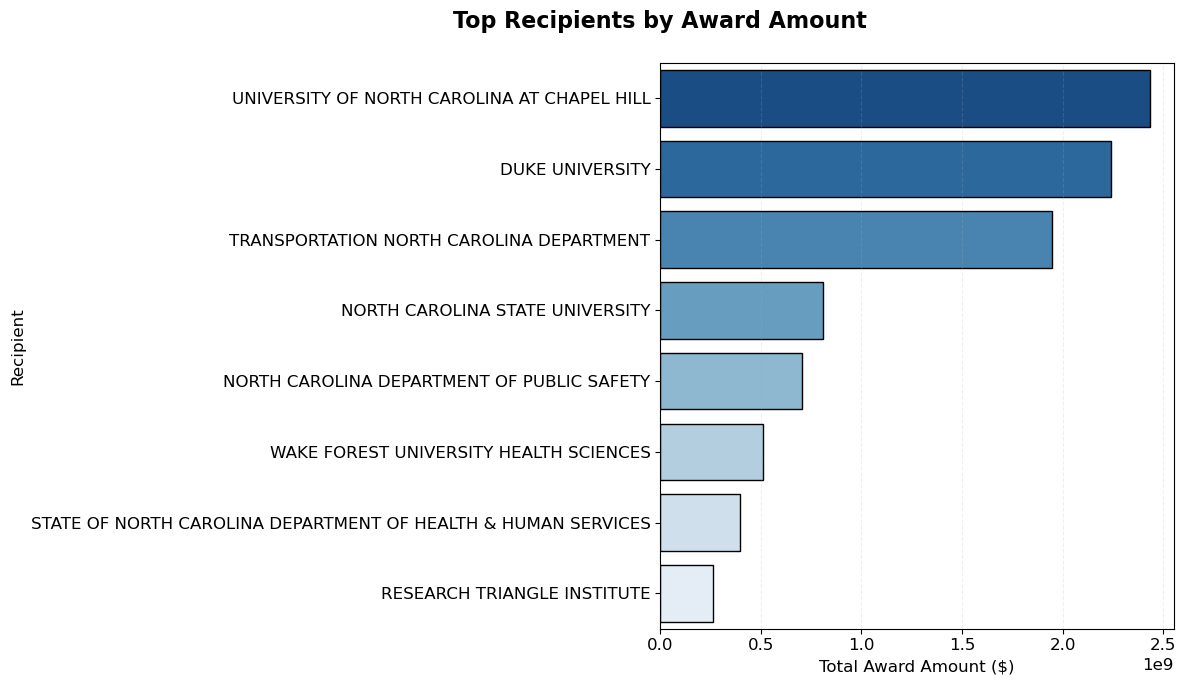

In [32]:
# Top Recipients (largest total award amounts)

top_n = 10

recipient_totals = (
    usaspending
    .groupby("recipient_name", dropna=False)["award_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
)

# Drop the first bar (the top 1 recipient)
recipient_totals = recipient_totals.iloc[1:]

recipient_totals = recipient_totals[recipient_totals.index != "REDACTED DUE TO PII"]

plt.figure(figsize=(12, 7))

# Use a blue color palette
colors = sns.color_palette("Blues_r", len(recipient_totals))

sns.barplot(
    x=recipient_totals.values,
    y=recipient_totals.index,
    palette=colors,
    orient="h",
    edgecolor='black'
)

plt.xlabel("Total Award Amount ($)", fontsize=12)
plt.ylabel("Recipient", fontsize=12)
plt.title(
    "Top Recipients by Award Amount\n",
    fontsize=16,
    fontweight='bold',
    x=0
)
plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()


In [16]:
# Merge Datasets
usa = usaspending.copy()
doge = doge_grant.copy()

usa["fain_key"]  = usa["award_id_fain"].astype(str).str.strip().str.upper()
doge["fain_key"] = doge["fain"].astype(str).str.strip().str.upper()

merged = doge.merge(
    usa,
    how="left",
    on="fain_key",             
    suffixes=("_doge", "_usa")
)

merged.head()

,date,agency,recipient,value,savings,link,description_doge,id,generated_unique_award_id,fain,uri,category,type,type_description,description_usas,subaward_count,total_subaward_amount,total_subsidy_cost,total_loan_value,total_obligation,date_signed,non_federal_funding,total_funding,total_account_outlay,total_account_obligation,account_outlays_by_defc,account_obligations_by_defc,record_type,cfda_info,transaction_obligated_amount,total_outlay,funding_agency_id,funding_agency_has_agency_page,funding_agency_toptier_agency_name,funding_agency_toptier_agency_code,funding_agency_toptier_agency_abbreviation,funding_agency_toptier_agency_slug,funding_agency_subtier_agency_name,funding_agency_subtier_agency_code,funding_agency_subtier_agency_abbreviation,funding_agency_office_agency_name,awarding_agency_id,awarding_agency_has_agency_page,awarding_agency_toptier_agency_name,awarding_agency_toptier_agency_code,awarding_agency_toptier_agency_abbreviation,awarding_agency_toptier_agency_slug,awarding_agency_subtier_agency_name,awarding_agency_subtier_agency_code,awarding_agency_subtier_agency_abbreviation,awarding_agency_office_agency_name,period_of_performance_start_date_doge,period_of_performance_end_date,period_of_performance_last_modified_date,recipient_recipient_hash,recipient_recipient_name,recipient_recipient_uei,recipient_recipient_unique_id,recipient_parent_recipient_hash,recipient_parent_recipient_name,recipient_parent_recipient_uei,recipient_parent_recipient_unique_id,recipient_business_categories,recipient_location_location_country_code,recipient_location_country_name,recipient_location_state_code,recipient_location_state_name,recipient_location_city_name,recipient_location_county_code,recipient_location_county_name,recipient_location_address_line1,recipient_location_address_line2,recipient_location_congressional_code,recipient_location_zip4,recipient_location_zip5,recipient_location_foreign_postal_code,recipient_location_foreign_province,executive_details_officers,place_of_performance_location_country_code,place_of_performance_country_name,place_of_performance_county_code,place_of_performance_county_name,place_of_performance_city_name,place_of_performance_state_code,place_of_performance_state_name,place_of_performance_congressional_code,place_of_performance_zip4,place_of_performance_zip5,place_of_performance_foreign_province,funding_opportunity_number_doge,funding_opportunity_goals,dt_scrape,fain_key,assistance_transaction_unique_key,assistance_award_unique_key,award_id_fain,modification_number,award_id_uri,sai_number,federal_action_obligation,total_obligated_amount,total_outlayed_amount_for_overall_award,indirect_cost_federal_share_amount,non_federal_funding_amount,total_non_federal_funding_amount,face_value_of_loan,original_loan_subsidy_cost,total_face_value_of_loan,total_loan_subsidy_cost,generated_pragmatic_obligations,disaster_emergency_fund_codes_for_overall_award,outlayed_amount_from_COVID-19_supplementals_for_overall_award,obligated_amount_from_COVID-19_supplementals_for_overall_award,outlayed_amount_from_IIJA_supplemental_for_overall_award,obligated_amount_from_IIJA_supplemental_for_overall_award,action_date,action_date_fiscal_year,period_of_performance_start_date_usa,period_of_performance_current_end_date,awarding_agency_code,awarding_agency_name,awarding_sub_agency_code,awarding_sub_agency_name,awarding_office_code,awarding_office_name,funding_agency_code,funding_agency_name,funding_sub_agency_code,funding_sub_agency_name,funding_office_code,funding_office_name,treasury_accounts_funding_this_award,federal_accounts_funding_this_award,object_classes_funding_this_award,program_activities_funding_this_award,recipient_uei,recipient_duns,recipient_name,recipient_name_raw,recipient_parent_uei,recipient_parent_duns,recipient_parent_name,recipient_parent_name_raw,recipient_country_code,recipient_country_name,recipient_address_line_1,recipient_address_line_2,recipient_city_code,recipient_city_name,prime_award_transaction_recipien

In [19]:
merged = merged[merged['savings']>0]
merged.shape

(252, 192)

In [ ]:
selected_cols = ['value', 'savings', 'description_doge', 'total_obligation', 'award_amount',
                 'link', 'fain_key', 'date', 'agency', 'funding_opportunity_goals', 
                 'total_obligated_amount', 'federal_action_obligation', 'non_federal_funding_amount', 'action_date', 
                 'action_date_fiscal_year', 'awarding_agency_name', 'awarding_sub_agency_name', 
                 'funding_office_name', 'recipient_name', 'recipient_parent_name', 'primary_place_of_performance_scope', 
                 'primary_place_of_performance_country_code', 'primary_place_of_performance_country_name', 
                 'primary_place_of_performance_state_name', 'cfda_title', 'business_types_description', 'action_type_description']

In [ ]:
merged_df = merged[selected_cols]
merged_df.head()

In [ ]:
merged_df = merged_df.dropna(subset=['award_amount'])
merged_df.shape

In [ ]:
merged_df.head()

#### Mapping for sector

In [ ]:
merged_df['cfda_title'].value_counts()

In [ ]:
merged_df['cfda_title'].unique()

In [ ]:
categories = {
    "Education": [
        'TEACHER AND SCHOOL LEADER INCENTIVE GRANTS (FORMERLY THE TEACHER INCENTIVE FUND)',
        'COMPREHENSIVE CENTERS',
        'TEACHER QUALITY PARTNERSHIP GRANTS',
        'SUPPORTING EFFECTIVE EDUCATOR DEVELOPMENT PROGRAM',
        'CITIZENSHIP EDUCATION AND TRAINING',
        'EDUCATION AND HUMAN RESOURCES',
        'STEM EDUCATION (FORMERLY EDUCATION AND HUMAN RESOURCES)',
        'LAURA BUSH 21ST CENTURY LIBRARIAN PROGRAM',
        'PROMOTION OF THE HUMANITIES TEACHING AND LEARNING RESOURCES AND CURRICULUM DEVELOPMENT',
        'SCIENCE, TECHNOLOGY, ENGINEERING & MATHEMATICS (STEM) EDUCATION, OUTREACH AND WORKFORCE PROGRAM'
    ],

    "Science and Innovation": [
        'SCIENTIFIC LEADERSHIP AWARDS',
        'BASIC SCIENTIFIC RESEARCH',
        'BASIC, APPLIED, AND ADVANCED RESEARCH IN SCIENCE AND ENGINEERING',
        'SOCIAL, BEHAVIORAL, AND ECONOMIC SCIENCES',
        'COMPUTER AND INFORMATION SCIENCE AND ENGINEERING',
        'INTEGRATIVE ACTIVITIES',
        'ENGINEERING',
        'SCIENCE TO ACHIEVE RESULTS (STAR) RESEARCH PROGRAM',
        'NSF TECHNOLOGY, INNOVATION, AND PARTNERSHIPS',
        'OFFICE OF RESEARCH AND DEVELOPMENT CONSOLIDATED RESEARCH/TRAINING/FELLOWSHIPS'
    ],

    "Environment Climate Agriculture": [
        'ENVIRONMENTAL JUSTICE COLLABORATIVE PROBLEM-SOLVING COOPERATIVE AGREEMENT PROGRAM',
        'PARTNERSHIPS FOR CLIMATE-SMART COMMODITIES',
        'AGRICULTURE AND FOOD RESEARCH INITIATIVE (AFRI)',
        'GEOSCIENCES'
    ],

    "Health and Human Development": [
        'CHILD HEALTH AND HUMAN DEVELOPMENT EXTRAMURAL RESEARCH'
    ],

    "Justice Social Equity and Community": [
        'FAIR HOUSING ORGANIZATION INITIATIVES',
        'NATIONAL INSTITUTE OF JUSTICE RESEARCH, EVALUATION, AND DEVELOPMENT PROJECT GRANTS',
        'NATIONAL LEADERSHIP GRANTS',
        'MUSEUMS FOR AMERICA',
        "SAVE AMERICA'S TREASURES",
        'PROMOTION OF THE HUMANITIES RESEARCH',
        'PROMOTION OF THE HUMANITIES FEDERAL/STATE PARTNERSHIP',
        'PROMOTION OF THE HUMANITIES PUBLIC PROGRAMS'
    ],

    "International Development": [
        'USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS'
    ]
}

In [ ]:
lookup = {}
for cat, items in categories.items():
    for title in items:
        lookup[title] = cat

def assign_category(title):
    return lookup.get(title, "Other") 

merged_df["sector"] = merged_df["cfda_title"].apply(assign_category)

In [ ]:
merged_df.head()

In [ ]:
merged_df.to_csv("merged_df.csv", index=False)